In [4]:
# %matplotlib widget

# =============================================================================
# CELL 5: 3D Feasible Space Manifold (Molzahn 2017, Figure 3 Replication)
# =============================================================================
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the dataset generated by your HPC parameter sweep
input_filename = "wb5_feasible_points_FINAL_2356.pkl"
if not os.path.exists(input_filename):
    raise FileNotFoundError(f"Could not find '{input_filename}'. Ensure it is in your notebook folder!")

with open(input_filename, "rb") as f:
    plot_points = pickle.load(f)

print(f"✔ Successfully loaded {len(plot_points):,} feasible points.")


✔ Successfully loaded 2,356 feasible points.


In [6]:
import pickle
import numpy as np

# Load your new strict dataset
with open("wb5_feasible_points_FINAL_2356.pkl", "rb") as f:
    points = pickle.load(f)

# Extract values
p_g5 = np.array([pt['P_gen'][4] for pt in points])
q_g5 = np.array([pt['Q_gen'][4] for pt in points])
v_mag = np.array([pt['V_mag'] for pt in points])

# Find index of the absolute highest P_G5 achieved
max_p_idx = np.argmax(p_g5)

print("=== MANIFOLD BOUNDARY DIAGNOSTICS ===")
print(f"Max $P_{{G5}}$ reached: {p_g5[max_p_idx]:.4f} pu")
print(f"Corresponding $Q_{{G5}}$: {q_g5[max_p_idx]:.4f} pu")
print("\nVoltage Profile at this boundary point:")
for bus_idx in range(len(v_mag[max_p_idx])):
    print(f"  Bus {bus_idx+1} Voltage: {v_mag[max_p_idx][bus_idx]:.4f} pu")

=== MANIFOLD BOUNDARY DIAGNOSTICS ===
Max $P_{G5}$ reached: 2.2711 pu
Corresponding $Q_{G5}$: -0.2783 pu

Voltage Profile at this boundary point:
  Bus 1 Voltage: 1.0500 pu
  Bus 2 Voltage: 0.9575 pu
  Bus 3 Voltage: 0.9505 pu
  Bus 4 Voltage: 0.9815 pu
  Bus 5 Voltage: 1.0500 pu


In [ ]:
# Check the global ranges in your saved dataset
print("=== DOCKING DATASET EXTREMES ===")
print(f"$P_{{G1}}$ Range: [{p_g5.min():.2f}, {p_g5.max():.2f}]")
print(f"$Q_{{G5}}$ Range: [{q_g5.min():.2f}, {q_g5.max():.2f}]")

=== DOCKING DATASET EXTREMES ===
$P_{G1}$ Range: [0.50, 2.27]
$Q_{G5}$ Range: [-0.30, -0.04]


✔ High-resolution plot saved as 'wb5_feasible_points_FINAL_50875points.pkl.png'!


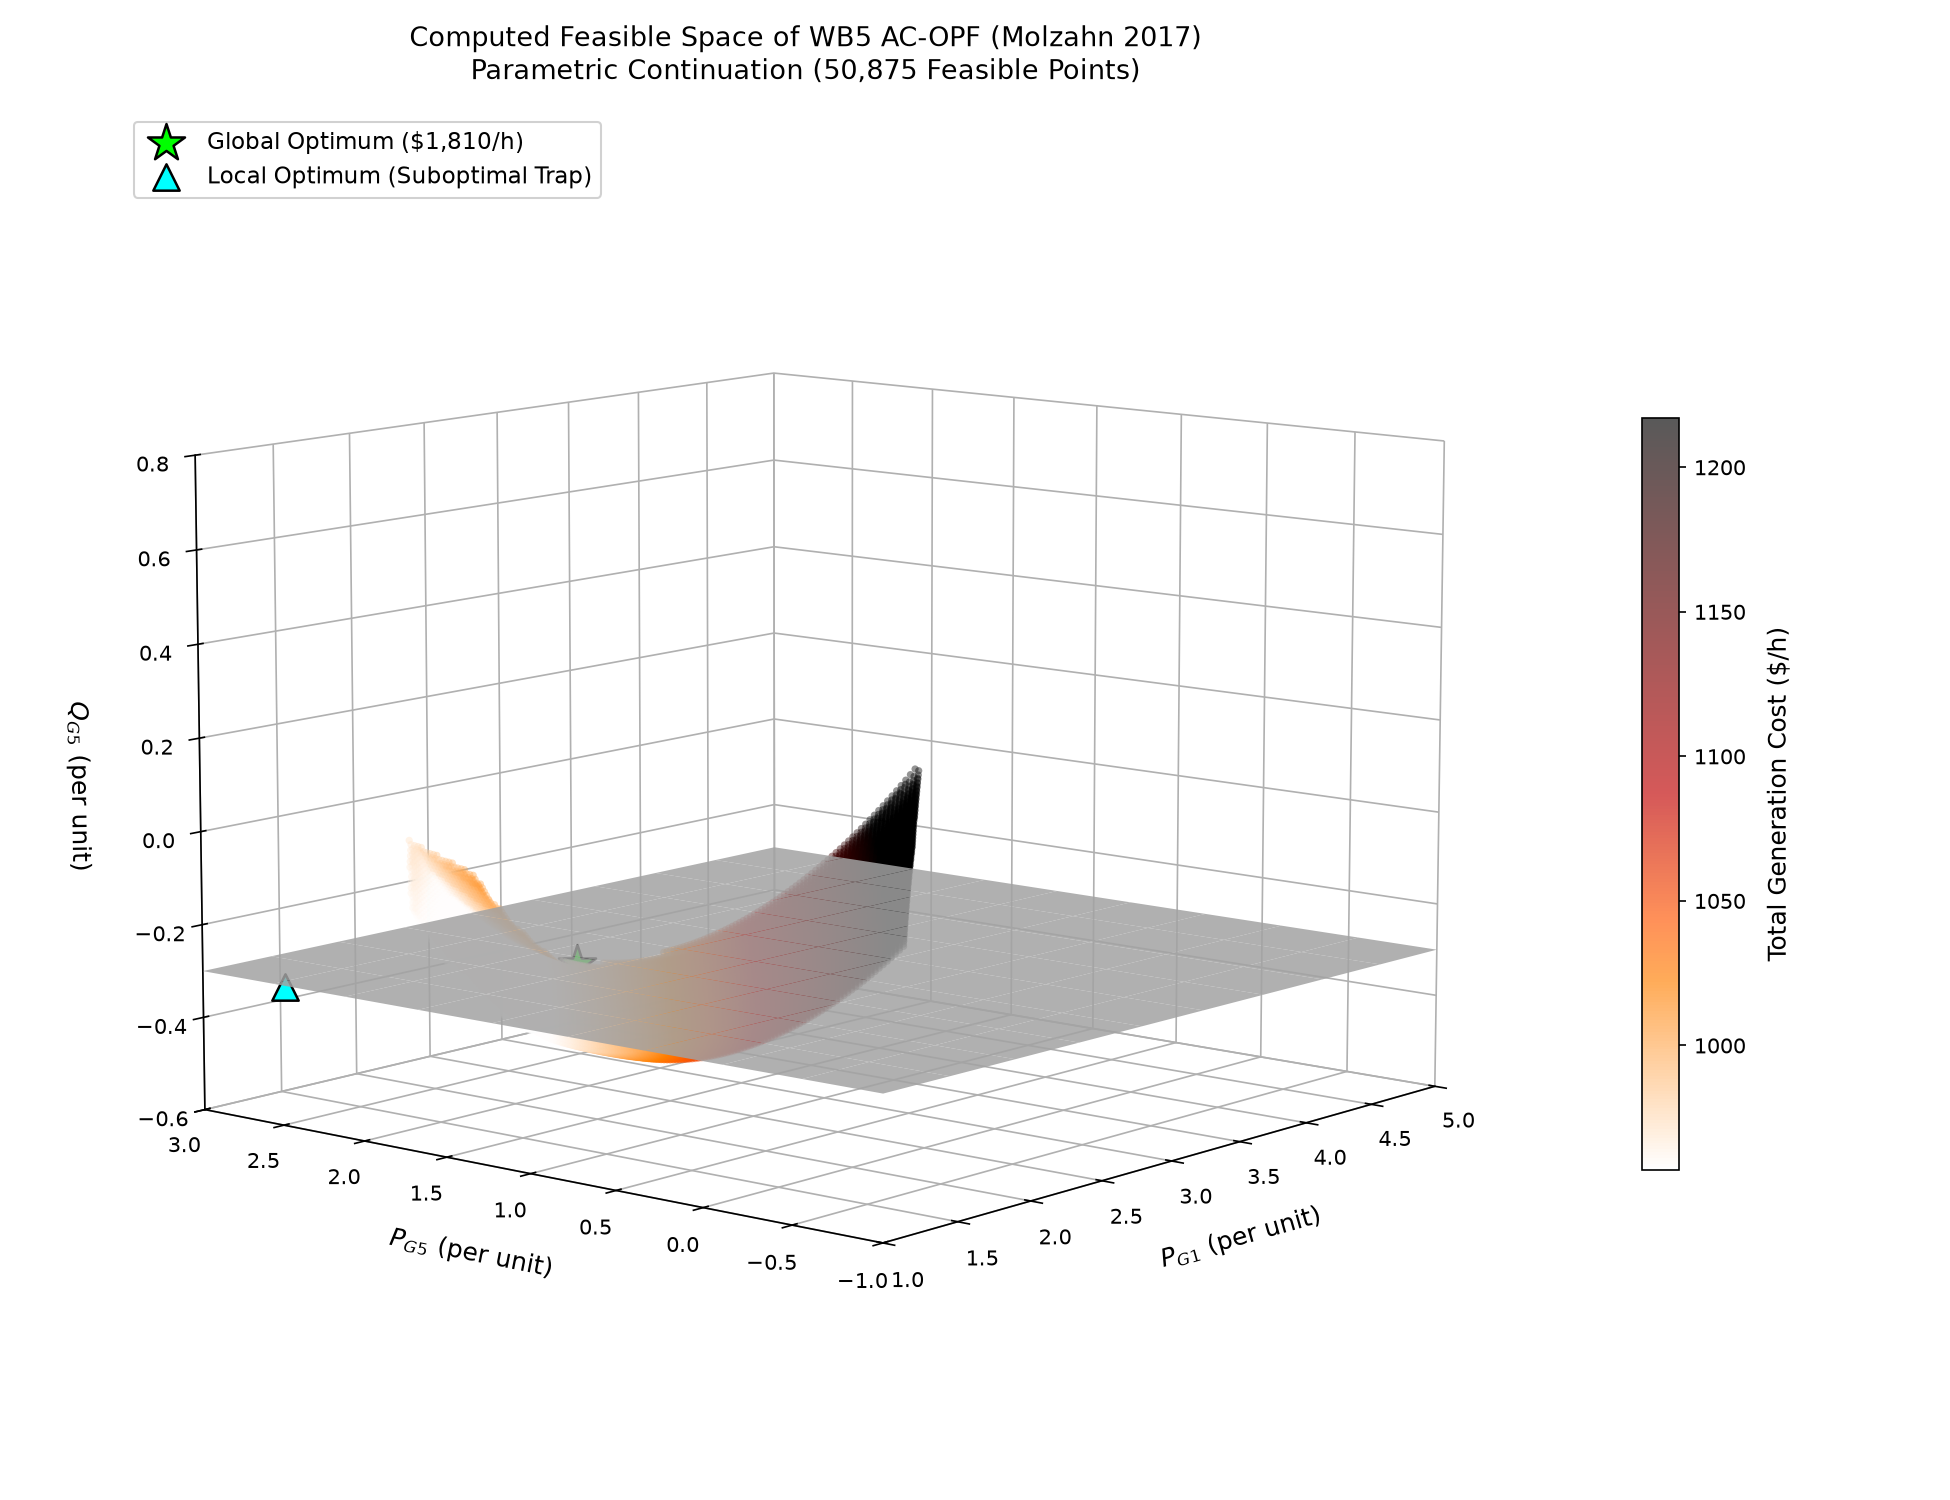

In [ ]:
# 2. Extract projection axes: P_G5 (X-axis), P_G1 (Y-axis), Q_G5 (Z-axis)
P_G1_vals = np.array([pt['P_gen'][0] for pt in plot_points])  # Slack bus active generation
P_G5_vals = np.array([pt['P_gen'][4] for pt in plot_points])  # Bus 5 active generation
Q_G5_vals = np.array([pt['Q_gen'][4] for pt in plot_points])  # Bus 5 reactive generation
cost_vals = np.array([pt['cost'] for pt in plot_points])      # Objective cost ($/h)

# Clean any potential NaN/Inf values
valid_mask = ~np.isnan(cost_vals) & ~np.isinf(cost_vals)
P_G1_vals, P_G5_vals, Q_G5_vals, cost_vals = P_G1_vals[valid_mask], P_G5_vals[valid_mask], Q_G5_vals[valid_mask], cost_vals[valid_mask]

# 3. Initialize 3D Figure
fig = plt.figure(figsize=(13, 10), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the Continuous Feasible Manifold (The "Ribbon")
# Using gist_heat_r mimics the paper's thermal gradient (White/Red -> Black)
sc = ax.scatter(P_G1_vals, P_G5_vals, Q_G5_vals, 
                c=cost_vals, cmap='gist_heat_r', 
                s=12,               # Size calibrated for 2,510 points to fuse into a surface
                alpha=0.65,         # Transparency allows volume structure to be visible
                edgecolors='none',  # Critical: Removes borders so points blend into a ribbon
                vmin=np.percentile(cost_vals, 5), vmax=np.percentile(cost_vals, 95))

# 5. Plot the Separating Hyperplane at Q_G5 = -0.30 pu
# This plane highlights the topological disconnect between the local and global optima
xx, yy = np.meshgrid(np.linspace(1.0, 5.0, 10), np.linspace(-1.0, 3.0, 10))
zz = -0.30 * np.ones_like(xx)
ax.plot_surface(xx, yy, zz, color='lightgray', alpha=0.85, rstride=1, cstride=1, edgecolor='none')

# 6. Highlight Benchmark Optima from Molzahn (2017) Table II
# Global Optimum: P_G1 = 1.81, P_G5 = 2.21, Q_G5 = -0.30 ($1,810/h)
ax.scatter([2.21], [1.81], [-0.30], color='lime', s=350, marker='*', 
           edgecolors='black', linewidths=1.2, zorder=10, label='Global Optimum ($1,810/h)')

# Local Optimum: P_G1 = 2.46, P_G5 = 0.98, Q_G5 = -0.30 (+14.3% higher cost)
ax.scatter([0.98], [2.46], [-0.30], color='cyan', s=160, marker='^', 
           edgecolors='black', linewidths=1.2, zorder=10, label='Local Optimum (Suboptimal Trap)')

# 7. Axes formatting and labels
cb = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.08)
cb.set_label('Total Generation Cost ($/h)', fontsize=12, labelpad=10)

ax.set_xlabel('$P_{G1}$ (per unit)', fontsize=12, labelpad=12)
ax.set_ylabel('$P_{G5}$ (per unit)', fontsize=12, labelpad=12)
ax.set_zlabel('$Q_{G5}$ (per unit)', fontsize=12, labelpad=12)

# --- CRITICAL AXIS SWAP ADJUSTMENTS ---
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))  
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.zaxis._axinfo['juggled'] = (0, 2, 0)
# -------------------------------------- default below
# ax.xaxis._axinfo['juggled'] = (1, 0, 2)
# ax.yaxis._axinfo['juggled'] = (0, 1, 2)
# ax.zaxis._axinfo['juggled'] = (0, 2, 1)

# Set exact viewing limits matching Figure 3
ax.set_xlim([1, 5])
ax.set_ylim([-1.0, 3.0])
ax.set_zlim([-0.60, 0.80])

# Invert the X-axis so P_G5 increases from right to left like the paper
# ax.invert_xaxis()
# ax.invert_yaxis()
# ax.invert_zaxis()

ax.set_title("Computed Feasible Space of WB5 AC-OPF (Molzahn 2017)\n"
             f"Parametric Continuation ({len(plot_points):,} Feasible Points)", fontsize=13, pad=15)

# Adjust camera viewpoint to naturally push the PG1 wall panel backward
ax.view_init(elev=10, azim=220)
ax.legend(loc='upper left', framealpha=0.9, fontsize=11)

plt.tight_layout()

# Save publication-ready image
output_img = f"{input_filename}_ipynb.png"
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print(f"✔ High-resolution plot saved as '{output_img}'!")

plt.show()

In [ ]:
1